# Smartphones in India, 2023
## Task 2 · Hypothesis testing and statistical inference

**T4EU Data Science Winter School, Katowice** · Team: Oleksandr Klepachevskyi, Sakthi Sivaram Manikandan

In Task 1 we cleaned the data and found some clear patterns. In this task we test them properly. Our question for the whole task is:

> **Do you pay for the specs, or for the brand?**

We test 6 hypotheses on the clean data from Task 1 (`data/smartphones_clean.csv`, 907 phones). We use the significance level **α = 0.05** for every test.

| # | Test | Our question |
|---|---|---|
| 1 | One-sample t-test | Is the average battery 5,000 mAh, the "standard" size? |
| 2 | One-sample test for a proportion | Can most phones pay contactlessly (NFC)? |
| 3 | Two-sample t-test | Do iPhones have better specs than Android flagships? |
| 4 | Two-sample t-test | Is a flagship worth twice the price? |
| 5 | Chi-square test of homogeneity | Do the five biggest brands follow the same price strategy? |
| 6 | Chi-square test of independence | Does having 5G depend on the brand? |

**How we run every test**
1. We state the null hypothesis H₀ and the alternative hypothesis H₁.
2. We check the assumptions of the test: normality with the Shapiro–Wilk test and equal variances with Levene's test (t-tests), or an expected count of at least 5 in every cell (chi-square tests).
3. We compute the test statistic and the p-value.
4. **Decision:** if p < α = 0.05, we reject H₀; otherwise we do not reject H₀.
5. We write the conclusion in plain words, and we also say **how big** the effect is, not only whether it is significant.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from pathlib import Path

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA = Path("data")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# We use the same chart style as in Task 1 (colour-blind-safe colours)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
SEGMENT_COLORS = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]      # Budget -> Flagship, light to dark
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 160,
})
def box_style(color=BLUE):
    return dict(patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=color + "1A", edgecolor=color, linewidth=1.5),
                medianprops=dict(color=INK, linewidth=2),
                whiskerprops=dict(color=color, linewidth=1.5), capprops=dict(color=color, linewidth=1.5),
                flierprops=dict(marker="o", markersize=3.5, markerfacecolor=MUTED, markeredgecolor="none", alpha=0.6))

inr = FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")    # 25000 -> "25k"

def save(fig, name):
    # We save every chart to figures/ so it can go straight into the slides
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")

df = pd.read_csv(DATA / "smartphones_clean.csv")
segments = ["Budget", "Mid-range", "Premium", "Flagship"]
df["price_segment"] = pd.Categorical(df["price_segment"], categories=segments, ordered=True)
print(f"Clean data from Task 1: {df.shape[0]} phones x {df.shape[1]} columns")

Clean data from Task 1: 907 phones x 61 columns


## Helper functions
These functions print every test in the same format, so the results are easy to read and to compare. We also collect each result for the summary table at the end.

In [2]:
ALPHA = 0.05
results = []          # we collect the result of every test here, for the summary at the end

def decision(p_value, alpha=ALPHA):
    return "Reject H0" if p_value < alpha else "Do not reject H0"

def print_result(test_name, h0, h1, statistic_name, statistic, p_value, alpha=ALPHA):
    print("=" * 78)
    print(test_name)
    print("-" * 78)
    print("H0:", h0)
    print("H1:", h1)
    print(f"{statistic_name} = {statistic:.4f}")
    print(f"p-value = {p_value:.4g}")
    print(f"alpha = {alpha}")
    print("Decision:", decision(p_value, alpha))
    if p_value < alpha:
        print("Interpretation: there is statistically significant evidence against H0.")
    else:
        print("Interpretation: there is not enough statistical evidence against H0.")

def shapiro_check(name, values, alpha=ALPHA):
    # Shapiro-Wilk test. H0: the population distribution is normal
    w, p = stats.shapiro(values)
    print(f"Shapiro-Wilk, {name}: W = {w:.4f}, p = {p:.4g} -> "
          + ("we cannot reject normality" if p >= alpha else "the distribution is not normal"))
    return p >= alpha

def levene_check(a, b, alpha=ALPHA):
    # Levene's test. H0: the two population variances are equal
    statistic, p = stats.levene(a, b, center="median")
    equal = p >= alpha
    print(f"Levene's test: statistic = {statistic:.4f}, p = {p:.4g} -> "
          + ("we treat the variances as equal, so we use Student's t-test" if equal
             else "the variances are different, so we use Welch's t-test"))
    return equal

def cohens_d(a, b):
    # Effect size: the difference between the two means, measured in pooled standard deviations
    pooled = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled

def cramers_v(table):
    # Effect size for a chi-square test: 0 = no relationship at all, 1 = a perfect relationship
    chi2 = stats.chi2_contingency(table)[0]
    return np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))

# Test 1 · One-sample t-test
## Is the average battery 5,000 mAh?
Most new phones are advertised with a 5,000 mAh battery, so many people think of it as the standard size. In Task 1 we saw that 5,000 mAh is the most common value (both the median and the mode). But is it also the **average**?

$\begin{cases}
H_0: \mu = 5000 \text{ mAh} \\
H_1: \mu \neq 5000 \text{ mAh}
\end{cases}$

Variable: `battery_capacity`, all 907 phones. We use a two-sided test with α = 0.05.

**Assumption check.** The one-sample t-test assumes that the population is normal, so we test that first with the Shapiro–Wilk test (H₀: the distribution is normal).

In [3]:
battery = df["battery_capacity"]
is_normal = shapiro_check("battery capacity", battery)

Shapiro-Wilk, battery capacity: W = 0.4718, p = 1.704e-45 -> the distribution is not normal


The battery distribution is not normal: half of all phones have exactly 5,000 mAh, and a few rugged phones have huge batteries. But we have 907 phones, so by the **central limit theorem** the sample mean is approximately normal anyway, and the t-test still gives reliable results.

In [4]:
mu0 = 5000
t_stat, p_value = stats.ttest_1samp(battery, popmean=mu0, alternative="two-sided")
print_result("One-sample t-test", "μ = 5000 mAh", "μ ≠ 5000 mAh", "t", t_stat, p_value)

# How big is the difference? We add a 95% confidence interval for the true mean and Cohen's d
ci_low, ci_high = stats.t.interval(0.95, df=len(battery) - 1, loc=battery.mean(), scale=stats.sem(battery))
print(f"\nSample mean = {battery.mean():,.1f} mAh | standard deviation = {battery.std():,.1f} | n = {len(battery)}")
print(f"95% confidence interval for the mean: {ci_low:,.0f} to {ci_high:,.0f} mAh")
print(f"Difference from 5,000: {battery.mean() - mu0:,.0f} mAh ({(battery.mean() - mu0) / mu0:.1%}) | "
      f"Cohen's d = {(battery.mean() - mu0) / battery.std():.2f}")
print(f"Phones below 5,000 mAh: {(battery < mu0).mean():.1%} | exactly 5,000: {(battery == mu0).mean():.1%} | "
      f"iPhones on average: {df.loc[df.brand_name == 'apple', 'battery_capacity'].mean():,.0f} mAh")

results.append({"Test": "1. One-sample t-test", "Question": "Is the average battery 5,000 mAh?",
                "Statistic": f"t = {t_stat:.2f}", "p-value": p_value, "Decision": decision(p_value)})

One-sample t-test
------------------------------------------------------------------------------
H0: μ = 5000 mAh
H1: μ ≠ 5000 mAh
t = -5.5716
p-value = 3.328e-08
alpha = 0.05
Decision: Reject H0
Interpretation: there is statistically significant evidence against H0.

Sample mean = 4,809.7 mAh | standard deviation = 1,028.7 | n = 907
95% confidence interval for the mean: 4,743 to 4,877 mAh
Difference from 5,000: -190 mAh (-3.8%) | Cohen's d = -0.19
Phones below 5,000 mAh: 37.7% | exactly 5,000: 51.3% | iPhones on average: 3,518 mAh


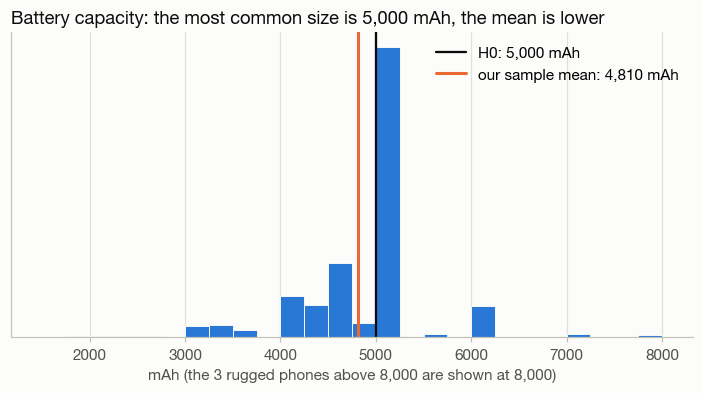

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(battery.clip(upper=8000), bins=np.arange(1500, 8250, 250), color=BLUE, edgecolor=SURFACE, linewidth=0.6)
ax.axvline(mu0, color=INK, linewidth=1.5, label="H0: 5,000 mAh")
ax.axvline(battery.mean(), color=ORANGE, linewidth=2, label=f"our sample mean: {battery.mean():,.0f} mAh")
ax.set_title("Battery capacity: the most common size is 5,000 mAh, the mean is lower")
ax.set_xlabel(f"mAh (the {(battery > 8000).sum()} rugged phones above 8,000 are shown at 8,000)")
ax.set_yticks([])
ax.grid(axis="y", visible=False)
ax.legend(loc="upper right")
save(fig, "t2_01_battery")
plt.show()

**Conclusion.** p < 0.001 < α = 0.05, so **we reject H₀**. The average battery in our data is **4,810 mAh**, and the 95% confidence interval (4,743–4,877 mAh) does not include 5,000.

So 5,000 mAh is the most common battery size (51.3% of phones have exactly 5,000 mAh), but it is not the average: 37.7% of phones have less, for example iPhones, with 3,518 mAh on average. The difference is statistically significant but small in practice: 190 mAh, or 3.8% (Cohen's d = −0.19).

# Test 2 · One-sample test for a population proportion
## Can most phones pay contactlessly (NFC)?
In Poland, where our winter school takes place, paying with a phone at the checkout is part of everyday life. It needs **NFC**, the chip for contactless payments. But our phones are from the Indian market, where most people pay differently: they scan a UPI QR code with the phone's camera. So is NFC still a standard feature there, found in at least half of the phones?

$\begin{cases}
H_0: p = 0.50 \\
H_1: p \neq 0.50
\end{cases}$

where p is the proportion of phones with NFC. Variable: `has_nfc` (1 = Yes, 0 = No), all 907 phones. We use a two-sided test with α = 0.05.

**Assumption check.** This z-test uses the normal approximation, which works when n·p₀ and n·(1 − p₀) are both at least 10.

In [6]:
nfc = df["has_nfc"]
success = int(nfc.sum())          # phones with NFC
n = len(nfc)
p0 = 0.50
print(f"n*p0 = {n * p0:.0f} and n*(1 - p0) = {n * (1 - p0):.0f}: both are at least 10, so the normal approximation works")

n*p0 = 454 and n*(1 - p0) = 454: both are at least 10, so the normal approximation works


In [7]:
z_stat, p_value = proportions_ztest(count=success, nobs=n, value=p0, alternative="two-sided")
print_result("One-sample test for a population proportion", "p = 0.50", "p ≠ 0.50", "z", z_stat, p_value)

# proportions_ztest uses the sample proportion in the standard error; the textbook formula uses p0. We check both.
z_textbook = (success / n - p0) / np.sqrt(p0 * (1 - p0) / n)
p_textbook = 2 * stats.norm.sf(abs(z_textbook))
print(f"\nCheck with the textbook formula z = (p_hat - p0) / sqrt(p0 * (1 - p0) / n): "
      f"z = {z_textbook:.4f}, p-value = {p_textbook:.4g} -> {decision(p_textbook)}")

# How far from 50% are we? We add a 95% confidence interval for the true proportion
ci_low, ci_high = proportion_confint(success, n, alpha=ALPHA)
print(f"\nObserved proportion with NFC = {success / n:.3f} ({success} of {n} phones)")
print(f"95% confidence interval for the true proportion: {ci_low:.3f} to {ci_high:.3f}")

results.append({"Test": "2. One-sample test for a proportion", "Question": "Can most phones pay contactlessly (NFC)?",
                "Statistic": f"z = {z_stat:.2f}", "p-value": p_value, "Decision": decision(p_value)})

One-sample test for a population proportion
------------------------------------------------------------------------------
H0: p = 0.50
H1: p ≠ 0.50
z = -6.8443
p-value = 7.686e-12
alpha = 0.05
Decision: Reject H0
Interpretation: there is statistically significant evidence against H0.

Check with the textbook formula z = (p_hat - p0) / sqrt(p0 * (1 - p0) / n): z = -6.6741, p-value = 2.488e-11 -> Reject H0

Observed proportion with NFC = 0.389 (353 of 907 phones)
95% confidence interval for the true proportion: 0.357 to 0.421


**Where is NFC?** We look at the share of phones with NFC in each price segment, and at the price of phones with and without it.

In [8]:
by_segment = df.groupby("price_segment", observed=True)["has_nfc"].mean().mul(100)
print(f"Median price with NFC: {df.loc[df.has_nfc == 1, 'price'].median():,.0f} | "
      f"without NFC: {df.loc[df.has_nfc == 0, 'price'].median():,.0f} | "
      f"iPhones with NFC: {df.loc[df.brand_name == 'apple', 'has_nfc'].mean():.0%}")
by_segment.round(1).to_frame("phones with NFC, %")

Median price with NFC: 39,999 | without NFC: 14,490 | iPhones with NFC: 100%


,"phones with NFC, %"
price_segment,
Budget,4.30
Mid-range,33.00
Premium,85.70
Flagship,97.10


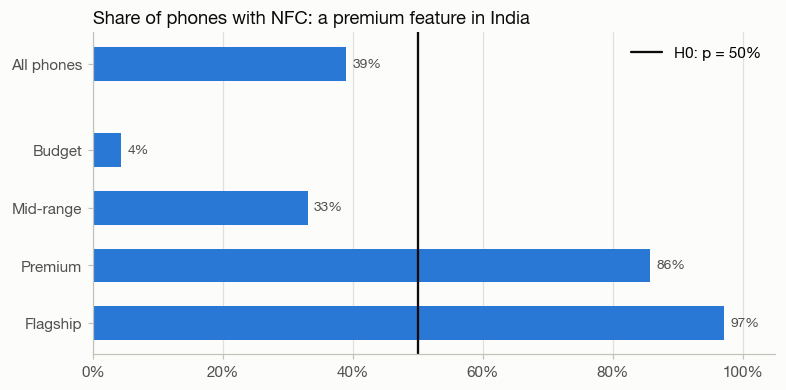

In [9]:
labels = ["All phones"] + segments
values = [success / n * 100] + list(by_segment.reindex(segments).values)
positions = [5.4, 3.6, 2.4, 1.2, 0]          # a small gap separates "All phones" from the segments

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(positions, values, height=0.7, color=BLUE)
for y, value in zip(positions, values):
    ax.text(value + 1, y, f"{value:.0f}%", va="center", fontsize=9, color=INK2)
ax.axvline(50, color=INK, linewidth=1.5, label="H0: p = 50%")
ax.set_yticks(positions, labels)
ax.set_xlim(0, 105)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
ax.legend(loc="upper right")
ax.set_title("Share of phones with NFC: a premium feature in India")
save(fig, "t2_02_nfc")
plt.show()

**Conclusion.** p < 0.001 < α = 0.05, so **we reject H₀**. Only **38.9%** of the phones have NFC (353 of 907), and the 95% confidence interval (35.7%–42.1%) lies clearly below 50%. So on the Indian market, NFC is **not** a standard feature. The textbook formula, which uses p₀ = 0.50 in the standard error, gives z = −6.67 and the same decision.

The chart shows why: NFC is a **premium feature**. Only 4.3% of Budget phones have it, against 85.7% of Premium and 97.1% of Flagship phones (and every iPhone). Phones with NFC cost a median ₹39,999, phones without it ₹14,490.

This fits the Indian market: most people pay by scanning UPI QR codes, which only needs a camera, so cheap phones can leave NFC out. In Poland, by contrast, paying contactlessly with a phone is part of everyday life.

# Test 3 · Two independent samples t-test
## Do iPhones have better specs than Android flagships?
iPhones are some of the most expensive phones. But do they also have the best specs? We compare iPhones with Android phones **in the same price segment** (Flagship, ₹60,000 or more), so that the comparison is fair. As the measure of the specs we use `rating`, the spec score from Smartprix (60–89).

In Task 1 we filled in missing ratings, mostly for expensive phones. A filled-in rating is our estimate, not a real score, so **here we use only measured ratings** (`rating_imputed == False`). This is exactly why we kept the flag columns.

$\begin{cases}
H_0: \mu_{iPhone} = \mu_{Android} \\
H_1: \mu_{iPhone} \neq \mu_{Android}
\end{cases}$

Variables: `rating` (measurement) and `brand_name` (grouping: Apple vs all other brands), Flagship phones only.

In [10]:
flagships = df[df["price_segment"] == "Flagship"].copy()
flagships["group"] = np.where(flagships["brand_name"] == "apple", "iPhone", "Android")
measured = flagships[~flagships["rating_imputed"]]
iphone = measured.loc[measured["group"] == "iPhone", "rating"]
android = measured.loc[measured["group"] == "Android", "rating"]
print(f"Flagship phones: {len(flagships)} | with a measured rating: {len(iphone)} iPhones, {len(android)} Android phones\n")

# First we look at the two groups: what do you get for the money?
flagships.groupby("group")[["price", "rating", "ram_capacity", "battery_capacity"]].median().rename(columns=lambda c: f"median {c}")

Flagship phones: 103 | with a measured rating: 31 iPhones, 34 Android phones



,median price,median rating,median ram_capacity,median battery_capacity
group,,,,
Android,"82,995.00",86.00,12.00,"4,700.00"
iPhone,"119,900.00",79.00,6.00,"3,279.00"


**Assumption checks.** We test the normality of each group with Shapiro–Wilk, and the equality of the two variances with Levene's test. Levene's test decides which t-test we use: Student's t-test if the variances are equal, Welch's t-test if they are not.

In [11]:
shapiro_check("iPhone ratings", iphone)
shapiro_check("Android ratings", android)
equal_var = levene_check(iphone, android)

Shapiro-Wilk, iPhone ratings: W = 0.9687, p = 0.4832 -> we cannot reject normality
Shapiro-Wilk, Android ratings: W = 0.7719, p = 7.655e-06 -> the distribution is not normal
Levene's test: statistic = 12.9121, p = 0.0006405 -> the variances are different, so we use Welch's t-test


In [12]:
t_stat, p_value = stats.ttest_ind(iphone, android, equal_var=equal_var)
test_name = "Student's independent samples t-test" if equal_var else "Welch's independent samples t-test"
print_result(test_name, "μ_iPhone = μ_Android", "μ_iPhone ≠ μ_Android", "t", t_stat, p_value)

# The ratings are not normal and the groups are small, so we confirm the result with a test that needs no normality
u_stat, u_p = stats.mannwhitneyu(iphone, android, alternative="two-sided")
print(f"\nCheck without the normality assumption (Mann-Whitney U test): U = {u_stat:.0f}, p = {u_p:.4g} -> {decision(u_p)}")
print(f"Mean rating: iPhone {iphone.mean():.1f}, Android {android.mean():.1f} | "
      f"difference {iphone.mean() - android.mean():.1f} points | Cohen's d = {cohens_d(iphone, android):.2f}")

results.append({"Test": "3. Two-sample t-test (Welch)" if not equal_var else "3. Two-sample t-test",
                "Question": "Do iPhones have better specs than Android flagships?",
                "Statistic": f"t = {t_stat:.2f}", "p-value": p_value, "Decision": decision(p_value)})

Welch's independent samples t-test
------------------------------------------------------------------------------
H0: μ_iPhone = μ_Android
H1: μ_iPhone ≠ μ_Android
t = -11.3737
p-value = 5.693e-15
alpha = 0.05
Decision: Reject H0
Interpretation: there is statistically significant evidence against H0.

Check without the normality assumption (Mann-Whitney U test): U = 20, p = 2.187e-11 -> Reject H0
Mean rating: iPhone 79.5, Android 87.4 | difference -7.9 points | Cohen's d = -2.89


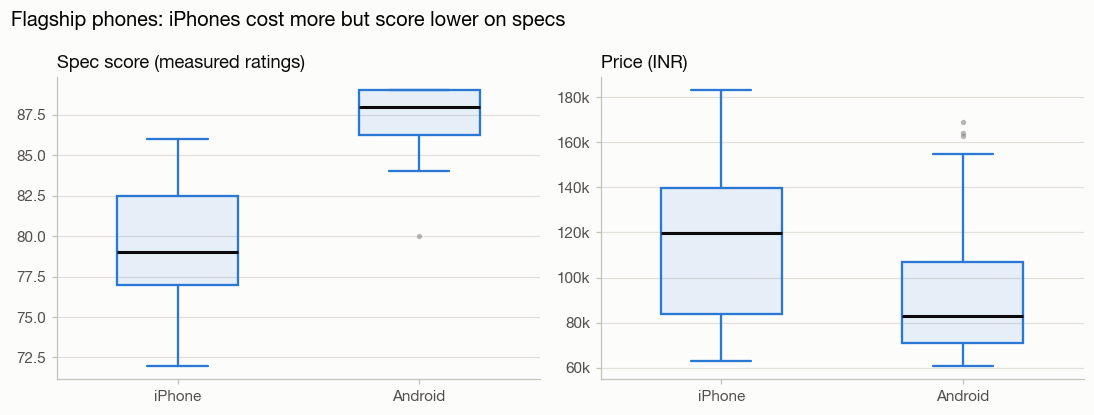

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].boxplot([iphone, android], **box_style())
axes[0].set_title("Spec score (measured ratings)")
price_groups = [flagships.loc[flagships["group"] == g, "price"] for g in ["iPhone", "Android"]]
axes[1].boxplot(price_groups, **box_style())
axes[1].set_title("Price (INR)")
axes[1].yaxis.set_major_formatter(inr)
for ax in axes:
    ax.set_xticks([1, 2], ["iPhone", "Android"])
    ax.grid(axis="x", visible=False)
fig.suptitle("Flagship phones: iPhones cost more but score lower on specs", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "t2_03_iphone_vs_android")
plt.show()

**Conclusion.** p < 0.001 < α = 0.05, so **we reject H₀**: iPhones and Android flagships do not have the same average spec score. And the difference goes the opposite way from what many people expect: iPhones score **79.5** on average, Android flagships **87.4**. The Mann–Whitney test gives the same result, and the effect is very large (Cohen's d = −2.89).

At the same time, iPhones cost more (median ₹119,900 vs ₹82,995), have half the RAM (6 vs 12 GB) and a smaller battery (3,279 vs 4,700 mAh). So **the iPhone price is not explained by its specs on paper**: buyers also pay for the brand, the ecosystem and the software.

*A limitation we have to mention:* the rating is a spec score that counts RAM, battery size, megapixels and so on. It does not measure software optimisation or how many years a phone gets updates, which are strengths of iPhones.

# Test 4 · Two independent samples t-test
## Is a flagship worth twice the price?
Flagship phones (₹60,000 or more) cost about twice as much as Premium phones (₹30,000–59,999). But are their specs also much better? We compare the spec score of the two segments.

For a fair comparison we use:
- **Android phones only:** iPhones have much lower spec scores (Test 3) and would pull the Flagship average down.
- **Measured ratings only:** in Task 1 we filled missing ratings with the median of the same price group, so filled-in ratings would create a difference between the segments by themselves.

$\begin{cases}
H_0: \mu_{Flagship} = \mu_{Premium} \\
H_1: \mu_{Flagship} \neq \mu_{Premium}
\end{cases}$

Variables:
- Grouping variable: `price_segment` (Premium vs Flagship)
- Measurement variable: `rating`

In [14]:
android_phones = df[(df["brand_name"] != "apple") & df["price_segment"].isin(["Premium", "Flagship"])]
price_premium = android_phones.loc[android_phones["price_segment"] == "Premium", "price_eur"]
price_flagship = android_phones.loc[android_phones["price_segment"] == "Flagship", "price_eur"]
print(f"Median price: Premium {price_premium.median():,.0f} EUR, Flagship {price_flagship.median():,.0f} EUR "
      f"(+{price_flagship.median() / price_premium.median() - 1:.0%})")

measured_android = android_phones[~android_phones["rating_imputed"]]
premium = measured_android.loc[measured_android["price_segment"] == "Premium", "rating"]
flagship = measured_android.loc[measured_android["price_segment"] == "Flagship", "rating"]
print(f"Android phones with a measured rating: {len(premium)} Premium, {len(flagship)} Flagship")

Median price: Premium 444 EUR, Flagship 922 EUR (+108%)
Android phones with a measured rating: 135 Premium, 34 Flagship


**Assumption checks**, the same as in Test 3: Shapiro–Wilk for each group, and Levene's test to choose between Student's and Welch's t-test.

In [15]:
shapiro_check("Flagship ratings", flagship)
shapiro_check("Premium ratings", premium)
equal_var = levene_check(flagship, premium)

Shapiro-Wilk, Flagship ratings: W = 0.7719, p = 7.655e-06 -> the distribution is not normal
Shapiro-Wilk, Premium ratings: W = 0.8170, p = 1.103e-11 -> the distribution is not normal
Levene's test: statistic = 4.1810, p = 0.04245 -> the variances are different, so we use Welch's t-test


In [16]:
t_stat, p_value = stats.ttest_ind(flagship, premium, equal_var=equal_var)
test_name = "Student's independent samples t-test" if equal_var else "Welch's independent samples t-test"
print_result(test_name, "μ_Flagship = μ_Premium", "μ_Flagship ≠ μ_Premium", "t", t_stat, p_value)

u_stat, u_p = stats.mannwhitneyu(flagship, premium, alternative="two-sided")
print(f"\nCheck without the normality assumption (Mann-Whitney U test): U = {u_stat:.0f}, p = {u_p:.4g} -> {decision(u_p)}")
print(f"Mean rating: Flagship {flagship.mean():.1f}, Premium {premium.mean():.1f} | difference {flagship.mean() - premium.mean():.1f} points "
      f"(+{flagship.mean() / premium.mean() - 1:.1%}) | Cohen's d = {cohens_d(flagship, premium):.2f}")

results.append({"Test": "4. Two-sample t-test" if equal_var else "4. Two-sample t-test (Welch)",
                "Question": "Is a flagship worth twice the price?",
                "Statistic": f"t = {t_stat:.2f}", "p-value": p_value, "Decision": decision(p_value)})

Welch's independent samples t-test
------------------------------------------------------------------------------
H0: μ_Flagship = μ_Premium
H1: μ_Flagship ≠ μ_Premium
t = 4.5210
p-value = 1.853e-05
alpha = 0.05
Decision: Reject H0
Interpretation: there is statistically significant evidence against H0.

Check without the normality assumption (Mann-Whitney U test): U = 3286, p = 8.664e-05 -> Reject H0
Mean rating: Flagship 87.4, Premium 85.5 | difference 2.0 points (+2.3%) | Cohen's d = 0.63


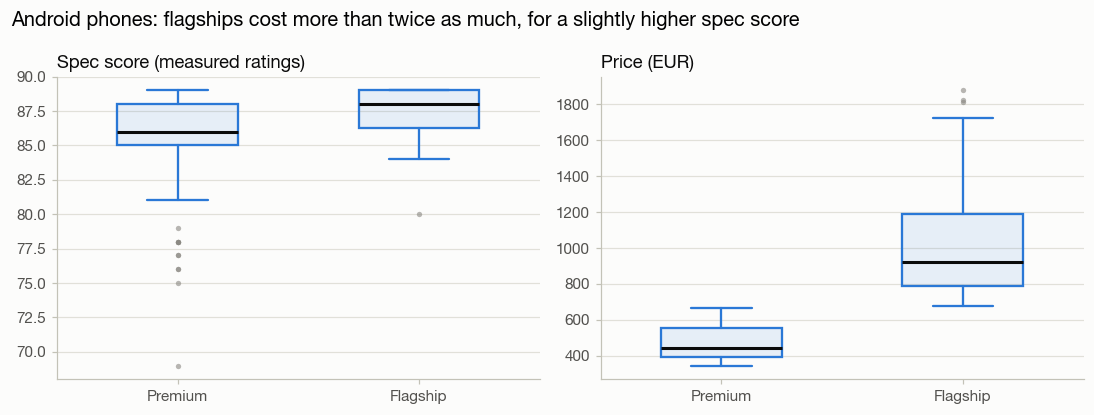

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].boxplot([premium, flagship], **box_style())
axes[0].set_title("Spec score (measured ratings)")
axes[1].boxplot([price_premium, price_flagship], **box_style())
axes[1].set_title("Price (EUR)")
for ax in axes:
    ax.set_xticks([1, 2], ["Premium", "Flagship"])
    ax.grid(axis="x", visible=False)
fig.suptitle("Android phones: flagships cost more than twice as much, for a slightly higher spec score",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "t2_04_flagship_vs_premium")
plt.show()

**Conclusion.** p < 0.001 < α = 0.05, so **we reject H₀**: flagships do have a higher average spec score than Premium phones, and the Mann–Whitney test agrees. But look at how big the difference is: **87.4 vs 85.5, only about 2 points (+2.3%)**, while flagships cost **more than twice as much** (median €922 vs €444, +108%).

This is a good example of the difference between **statistical and practical significance**: the difference is real (Cohen's d = 0.63), but small compared with the price. For most buyers, a Premium phone gives almost the same specs for less than half the money.

# Test 5 · Chi-square (χ²) test of homogeneity
## Do the five biggest brands follow the same price strategy?
We take the five brands with the most phones and compare how their phones are spread over the four price segments from Task 1.

$\begin{cases}
H_0: \text{the distribution of price segments is the same for all five brands} \\
H_1: \text{at least one brand has a different distribution}
\end{cases}$

Variables: `brand_name` (5 brands) and `price_segment` (Budget, Mid-range, Premium, Flagship).

In [18]:
top5 = df["brand_name"].value_counts().head(5).index.tolist()
brands = df[df["brand_name"].isin(top5)]
print("The five biggest brands:", top5, f"({len(brands)} phones)")

observed = pd.crosstab(brands["brand_name"], brands["price_segment"])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)
expected = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

print("\nObserved frequencies:")
display(observed)
print("Expected frequencies if H0 were true:")
display(expected.round(1))
print(f"Smallest expected count: {expected.values.min():.1f} (the test needs at least 5 in every cell)")

The five biggest brands: ['xiaomi', 'samsung', 'vivo', 'realme', 'oppo'] (530 phones)

Observed frequencies:


price_segment,Budget,Mid-range,Premium,Flagship
brand_name,,,,
oppo,22,38,14,7
realme,48,38,8,0
samsung,38,38,23,23
vivo,36,49,15,7
xiaomi,55,51,16,4


Expected frequencies if H0 were true:


price_segment,Budget,Mid-range,Premium,Flagship
brand_name,,,,
oppo,30.40,32.70,11.60,6.30
realme,35.30,38.00,13.50,7.30
samsung,45.80,49.30,17.50,9.40
vivo,40.20,43.20,15.30,8.30
xiaomi,47.30,50.90,18.10,9.70


Smallest expected count: 6.3 (the test needs at least 5 in every cell)


In [19]:
print_result("Chi-square test of homogeneity",
             "the distribution of price segments is the same for all five brands",
             "at least one brand has a different distribution", "χ²", chi2_stat, p_value)
print(f"degrees of freedom = {dof} | Cramér's V = {cramers_v(observed):.2f}")

results.append({"Test": "5. Chi-square test of homogeneity", "Question": "Do the biggest brands follow the same price strategy?",
                "Statistic": f"χ² = {chi2_stat:.1f}, df = {dof}", "p-value": p_value, "Decision": decision(p_value)})

# Row percentages: what share of each brand's phones is in each segment?
pd.crosstab(brands["brand_name"], brands["price_segment"], normalize="index").mul(100).round(1)

Chi-square test of homogeneity
------------------------------------------------------------------------------
H0: the distribution of price segments is the same for all five brands
H1: at least one brand has a different distribution
χ² = 49.2520
p-value = 1.89e-06
alpha = 0.05
Decision: Reject H0
Interpretation: there is statistically significant evidence against H0.
degrees of freedom = 12 | Cramér's V = 0.18


price_segment,Budget,Mid-range,Premium,Flagship
brand_name,,,,
oppo,27.20,46.90,17.30,8.60
realme,51.10,40.40,8.50,0.00
samsung,31.10,31.10,18.90,18.90
vivo,33.60,45.80,14.00,6.50
xiaomi,43.70,40.50,12.70,3.20


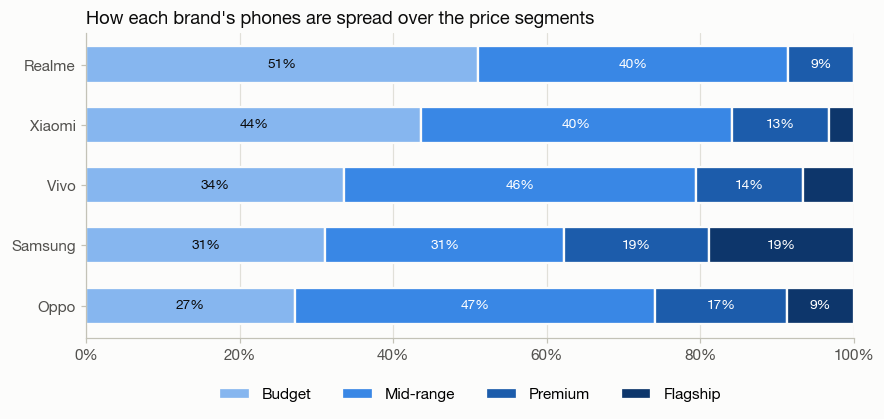

In [20]:
shares = pd.crosstab(brands["brand_name"], brands["price_segment"], normalize="index").mul(100)
shares = shares.sort_values("Budget")

fig, ax = plt.subplots(figsize=(9, 3.6))
left = np.zeros(len(shares))
for segment, color in zip(segments, SEGMENT_COLORS):
    values = shares[segment].values
    ax.barh(shares.index.str.title(), values, left=left, height=0.6, color=color,
            edgecolor=SURFACE, linewidth=1.5, label=segment)
    for y, (start, value) in enumerate(zip(left, values)):
        if value >= 8:          # only label segments that are wide enough for the text
            ax.text(start + value / 2, y, f"{value:.0f}%", ha="center", va="center", fontsize=9,
                    color=INK if color == SEGMENT_COLORS[0] else "white")
    left += values
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
ax.set_title("How each brand's phones are spread over the price segments")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
save(fig, "t2_05_brand_price_strategy")
plt.show()

**Conclusion.** p < 0.001 < α = 0.05, so **we reject H₀**: the five biggest brands do not follow the same price strategy. The chart shows how they differ:
- **Realme** is a budget brand: 51.1% of its phones are Budget phones, and it has no flagships at all.
- **Samsung** covers the whole market and has by far the most flagships (18.9% of its phones).
- **Xiaomi** focuses on cheaper phones (43.7% Budget, only 3.2% Flagship), while **Oppo** and **Vivo** focus on the mid-range (46.9% and 45.8%).

Cramér's V = 0.18, so the relationship is real but small to moderate: the brands also overlap a lot, especially in the mid-range. All expected counts are at least 6.3, so the test is valid.

# Test 6 · Chi-square (χ²) test of independence
## Does having 5G depend on the brand?
In Task 1 we saw that 5G depends strongly on the price segment. But do some brands simply push 5G more than others? We use the same five brands.

$\begin{cases}
H_0: \text{having 5G and the brand are independent} \\
H_1: \text{having 5G depends on the brand}
\end{cases}$

Variables: `brand_name` (5 brands) and `has_5g_label` (Yes / No).

In [21]:
observed = pd.crosstab(brands["brand_name"], brands["has_5g_label"])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)
expected = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

print("Observed frequencies:")
display(observed)
print("Expected frequencies if H0 were true:")
display(expected.round(1))
print(f"Smallest expected count: {expected.values.min():.1f} (the test needs at least 5 in every cell)")

Observed frequencies:


has_5g_label,No,Yes
brand_name,,
oppo,34,47
realme,44,50
samsung,63,59
vivo,57,50
xiaomi,59,67


Expected frequencies if H0 were true:


has_5g_label,No,Yes
brand_name,,
oppo,39.30,41.70
realme,45.60,48.40
samsung,59.20,62.80
vivo,51.90,55.10
xiaomi,61.10,64.90


Smallest expected count: 39.3 (the test needs at least 5 in every cell)


In [22]:
print_result("Chi-square test of independence", "having 5G and the brand are independent",
             "having 5G depends on the brand", "χ²", chi2_stat, p_value)
print(f"degrees of freedom = {dof} | Cramér's V = {cramers_v(observed):.2f}")

results.append({"Test": "6. Chi-square test of independence", "Question": "Does having 5G depend on the brand?",
                "Statistic": f"χ² = {chi2_stat:.1f}, df = {dof}", "p-value": p_value, "Decision": decision(p_value)})

share_5g = brands.groupby("brand_name")["has_5g"].mean().mul(100).sort_values()
share_5g.round(1).to_frame("share of 5G phones, %")

Chi-square test of independence
------------------------------------------------------------------------------
H0: having 5G and the brand are independent
H1: having 5G depends on the brand
χ² = 3.0862
p-value = 0.5435
alpha = 0.05
Decision: Do not reject H0
Interpretation: there is not enough statistical evidence against H0.
degrees of freedom = 4 | Cramér's V = 0.08


,"share of 5G phones, %"
brand_name,
vivo,46.70
samsung,48.40
xiaomi,53.20
realme,53.20
oppo,58.00


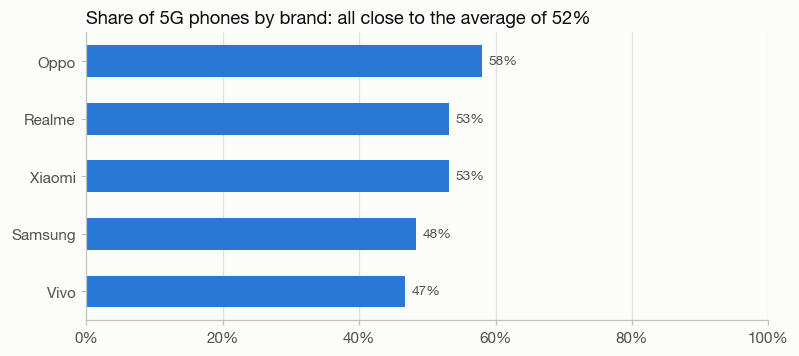

In [23]:
overall = brands["has_5g"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(share_5g.index.str.title(), share_5g.values, height=0.55, color=BLUE)
for y, value in enumerate(share_5g.values):
    ax.text(value + 1, y, f"{value:.0f}%", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
ax.set_title(f"Share of 5G phones by brand: all close to the average of {overall:.0f}%")
save(fig, "t2_06_5g_by_brand")
plt.show()

**Conclusion.** p = 0.544 > α = 0.05, so **we do not reject H₀**: we found no evidence that having 5G depends on the brand. Between 47% (Vivo) and 58% (Oppo) of each brand's phones have 5G, close to the average of the five brands (52%), and Cramér's V is only 0.08.

Together with Task 1, this tells a clear story: **5G depends on the price of a phone, not on its brand.** In Task 1, only 13% of Budget phones had 5G, against 94% of Premium phones.

# Summary of Task 2
All six tests at α = 0.05:

In [24]:
summary = pd.DataFrame(results)
summary["p-value"] = summary["p-value"].map(lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}")
summary

,Test,Question,Statistic,p-value,Decision
0,1. One-sample t-test,"Is the average battery 5,000 mAh?",t = -5.57,< 0.001,Reject H0
1,2. One-sample test for a proportion,Can most phones pay contactlessly (NFC)?,z = -6.84,< 0.001,Reject H0
2,3. Two-sample t-test (Welch),Do iPhones have better specs than Android flag...,t = -11.37,< 0.001,Reject H0
3,4. Two-sample t-test (Welch),Is a flagship worth twice the price?,t = 4.52,< 0.001,Reject H0
4,5. Chi-square test of homogeneity,Do the biggest brands follow the same price st...,"χ² = 49.3, df = 12",< 0.001,Reject H0
5,6. Chi-square test of independence,Does having 5G depend on the brand?,"χ² = 3.1, df = 4",0.544,Do not reject H0


**Our answer: do you pay for the specs or for the brand?**

| Test | Decision | What it means |
|---|---|---|
| 1. Battery = 5,000 mAh? | Reject H₀ | 5,000 mAh is the most common battery, but the average is lower (4,810 mAh). |
| 2. NFC in half of the phones? | Reject H₀ | Only 39% of phones have NFC: it's a premium feature (4% of Budget phones vs 97% of Flagships). |
| 3. iPhone vs Android | Reject H₀ | iPhones score lower on specs than Android flagships, but cost more: you also pay for the brand. |
| 4. Flagship vs Premium | Reject H₀ | Flagships score only about 2 points higher (+2.3%) for more than double the price. |
| 5. Brand × price segment | Reject H₀ | Brands follow different price strategies (Realme budget, Samsung flagships). |
| 6. Brand × 5G | Do not reject H₀ | 5G depends on the price, not on the brand. |

So for most phones **you pay for the specs**: in Task 1, the price followed processor speed, RAM and storage, and features like NFC (Test 2) and 5G (Test 6) come with the price, not with the brand. But **the extra money buys less and less**: a flagship costs more than twice as much as a Premium phone for 2.3% better specs (Test 4). **iPhones are the exception, where you also pay for the brand** (Test 3).

**What we keep in mind**
- **Statistical vs practical significance:** with about 900 phones, even small differences become significant. That's why we also report effect sizes and confidence intervals. For example, the battery difference is significant but small (3.8%), and so is the flagship advantage (2.3%).
- **"Do not reject H₀" is not proof** that there is no difference. It means that our data doesn't show one.
- **Several tests:** we ran 6 tests at α = 0.05, so there is a small chance that one result is a false alarm. Our significant p-values are all below 0.001, so they would stay significant even with a stricter threshold (Bonferroni: 0.05 / 6 ≈ 0.008).
- **Correlation is not causation:** our data is observational. A test shows that a difference exists, not what causes it.

**Next, Task 3:** linear regression to predict the price from the specs, and logistic regression to predict whether a phone has 5G.